In [ ]:
###===================WARNING===================###
''' 
Þegar þessi hluti er keyrður þá mun hann reyna að 
pip intsall-a numpy, prettytable og matplotlib.

Kóðin mun spyrja um leyfi y/n fyrir hvern package
ef hann er ekki nú þegar til staðar.

Ef þeir eru nú þegar í tölvunni mun kóðin skila 
"{package name} is already installed."
'''
###=============================================###

import subprocess
import sys

required_packages = [
    "numpy",
    "matplotlib",
    "scipy",
    "datetime"
]

def install_if_missing(package):
    try:
        __import__(package)
        print(f"{package} is already installed.")
    except ImportError:
        print(f"{package} is missing.")
        choice = input(f"Do you want to install '{package}'? (y/n): ").strip().lower()

        if choice == "y":
            print(f"Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        else:
            print(f"Skipped installing {package}.")

for pkg in required_packages:
    install_if_missing(pkg)

In [ ]:
import numpy as np
import scipy.sparse as sp
import math
import matplotlib.pyplot as plt
import time


def makePartOfA(jStart, jEnd, iFormula, iPlus, values, jLoc):
    coordVals = set()
    for s, j in enumerate(range(jStart, jEnd+1)):
        i = iFormula(j)
        temp_coords = []
        for k, x in enumerate(values):
            temp_coords.append((x, jLoc, i+iPlus[k]-1))
        coordVals.add(frozenset(temp_coords))
        jLoc += 1
    
    return coordVals, jLoc

def vinstriEfri(n, m, H, K, P, delta, Lx, Ly, L):
    hx = Lx / (m-1)
    
    jStart = math.floor((L/Ly)*(n-1))+1
    jEnd = n-1

    iFormula = lambda j: j*m+1
    
    iPlus = [0, 1, 2]

    values = [(2*H*hx/K)-3, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def vinstriNedri(n, m, H, K, P, delta, Lx, Ly, L):
    jStart = 0
    jEnd = math.floor((L/Ly)*(n-1))

    iFormula = lambda j: j*m+1

    iPlus = [0, 1, 2]

    values = [-3, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def haegri(n, m, H, K, P, delta, Lx, Ly, L):
    hx = Lx / (m-1)

    jStart = 1
    jEnd = n

    iFormula = lambda j: j*m

    iPlus = [0, -1, -2]

    values = [-3+(2*H*hx)/K, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def nidri(n, m, H, K, P, delta, Lx, Ly, L):
    hy = Ly / (n-1)

    jStart = 2
    jEnd = m-1

    iFormula = lambda j: j

    iPlus = [0, m, 2*m]

    values = [-3+(2*H*hy)/K, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def uppi(n, m, H, K, P, delta, Lx, Ly, L):
    hy = Ly / (n-1)

    jStart = n*m-m+2
    jEnd = n*m-1

    iFormula = lambda j: j

    iPlus = [0, -m, -2*m]

    values = [-3+(2*H*hy)/K, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def innriRod(n, m, H, K, P, delta, Lx, Ly, L, r):
    hx = Lx / (m-1)
    hy = Ly / (n-1)

    jStart = r*m+2
    jEnd = r*m+m-1

    iFormula = lambda j: j

    iPlus = [-m, -1, 0, 1, m]

    values = [hx**2, hy**2, -2*(hx**2+hy**2+(H*(hx**2)*(hy**2))/(K*delta)), hy**2, hx**2]

    return jStart, jEnd, iFormula, iPlus, values


def build_system(breytur: list): 
    '''Breytur = [n, m, H, K, P, delta, Lx, Ly, L]'''

    N = breytur[0] * breytur[1]

    vinstriEfriA = makePartOfA(*vinstriEfri(*breytur))
    vinstriNedriA = makePartOfA(*vinstriNedri(*breytur))
    nidriA = makePartOfA(*nidri(*breytur))
    uppiA = makePartOfA(*uppi(*breytur))
    haegriA = makePartOfA(*haegri(*breytur))
    innriRod1 = makePartOfA(*innriRod(*breytur,1))
    innriRod2 = makePartOfA(*innriRod(*breytur,2))
    innriRod3 = makePartOfA(*innriRod(*breytur,3))  

    # Build matrix a from parts hear
    all_parts = [
        vinstriEfriA,
        vinstriNedriA,
        nidriA,
        uppiA,
        haegriA,
        innriRod1,
        innriRod2,
        innriRod3
    ]

    rows = []
    cols = []
    vals = []

    for part in all_parts:
        for idx, val in part:
            row = idx - 1
            rows.append(row)
            cols.append(row)
            vals.append(val)

        A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))

    return A

def doEverything(n, m, H=0.005, K=1.68, P=5, delta=0.1, Lx=2, Ly=2, L=2, U=20):
    hx = Lx/(m-1)

    breytur = [n, m, H, K, P, delta, Lx, Ly, L]

    jLoc_use = 0
    innriPunktar = set()
    for k in range(1, n-1):   
        inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
        jLoc_use = jLoc
        for x in inner_row:
            innriPunktar.add(x)
    a1 = vinstriEfri(*breytur)
    a2 = vinstriNedri(*breytur)
    a3 = nidri(*breytur)
    a4 = uppi(*breytur)
    a5 = haegri(*breytur)
    
    vinstriEfri_A, jLoc0 = makePartOfA(*a1, jLoc)
    vinstriNedri_A, jLoc1 = makePartOfA(*a2, jLoc0)
    nidri_A, jLoc0 = makePartOfA(*a3, jLoc1)
    uppi_A, jLoc1 = makePartOfA(*a4, jLoc0)
    haegri_A, jLoc0 = makePartOfA(*a5, jLoc1)

    megalist = [
        *[x for y in vinstriEfri_A for x in y],
        *[x for y in vinstriNedri_A for x in y],
        *[x for y in nidri_A for x in y],
        *[x for y in uppi_A for x in y],
        *[x for y in haegri_A for x in y],
        *[x for y in innriPunktar for x in y]
    ]

    _, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
    length = len(list(set(vinstriNedriRows)))

    vinstriNedriRows = np.array(list(set(vinstriNedriRows)))
    bValues = np.array([-2*P*hx/(L*delta*K) for _ in range(length)])
    columns = np.array([0 for x in range(length)])

    b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)), shape=(n*m, 1)).tocsr()

    values, rows, cols = map(np.array, zip(*megalist))
    A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

    sol = sp.linalg.spsolve(A, b)

    u = np.asarray(sol).reshape((n, m))

    T = u + U                         

    plt.imshow(T, origin="lower", extent=[0, Lx, 0, Ly], aspect="auto")
    plt.colorbar(label="Temperature (°C)")
    plt.xlabel("x (cm)")
    plt.ylabel("y (cm)")
    plt.show()

def vinstriKalt(n, m, H, K, P, delta, Lx, Ly, L, jStart, jEnd):
    hx = Lx / (m-1)
    
    # jStart = math.floor((L/Ly)*(n-1))+1
    # jEnd = n-1

    iFormula = lambda j: j*m+1
    
    iPlus = [0, 1, 2]

    values = [(2*H*hx/K)-3, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values

def vinstriHeitt(n, m, H, K, P, delta, Lx, Ly, L, jStart, jEnd):
    # jStart = 0
    # jEnd = math.floor((L/Ly)*(n-1))

    iFormula = lambda j: j*m+1

    iPlus = [0, 1, 2]

    values = [-3, 4, -1]

    return jStart, jEnd, iFormula, iPlus, values


def best_cpu_placement(Lx=10, Ly=10, delta=0.1, P=5, K=1.68, H=0.005, U=20, n=200, m=200, POWER_START=0, POWER_END=9,L=9):


    hot_start = math.ceil(n*POWER_START/Ly)
    hot_end = math.floor(n*POWER_END/Ly)
    hx = Lx/(m-1)

    breytur = [n, m, H, K, P, delta, Lx, Ly, L]

    jLoc_use = 0
    innriPunktar = set()
    for k in range(1, n-1):   
        inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
        jLoc_use = jLoc
        for x in inner_row:
            innriPunktar.add(x)


    vinstriKalt1, jLoc0 = makePartOfA(*vinstriKalt(*breytur, 0, hot_start-1), jLoc)
    vinstriKalt2, jLoc1 = makePartOfA(*vinstriKalt(*breytur, hot_end+1, n-1), jLoc0)
    vinstriEfri_A, jLoc0 = vinstriKalt1.union(vinstriKalt2), jLoc1
    vinstriNedri_A, jLoc1 = makePartOfA(*vinstriHeitt(*breytur, hot_start, hot_end), jLoc0)
    nidri_A, jLoc0 = makePartOfA(*nidri(*breytur), jLoc1)
    uppi_A, jLoc1 = makePartOfA(*uppi(*breytur), jLoc0)
    haegri_A, jLoc0 = makePartOfA(*haegri(*breytur), jLoc1)

    megalist = [
        *[x for y in vinstriEfri_A for x in y],
        *[x for y in vinstriNedri_A for x in y],
        *[x for y in nidri_A for x in y],
        *[x for y in uppi_A for x in y],
        *[x for y in haegri_A for x in y],
        *[x for y in innriPunktar for x in y]
    ]

    _, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
    length = len(list(set(vinstriNedriRows)))

    vinstriNedriRows = np.array(list(set(vinstriNedriRows)))
    bValues = (-2*P*hx/(L*delta*K))*np.ones(length)
    columns = np.zeros(length)

    b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)), shape=(n*m, 1)).tocsr()

    values, rows, cols = map(np.array, zip(*megalist))
    A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

    sol = sp.linalg.spsolve(A, b)

    u = np.asarray(sol).reshape((n, m))

    T = u + U
    
    return T

def solve_once(n):
    Lx = Ly = 2
    delta = 0.1
    P = 5
    K = 1.68
    H = 0.005
    U = 20
    L = 2
    m = n

    hx = Lx/(m-1)

    breytur = [n, m, H, K, P, delta, Lx, Ly, L]

    jLoc_use = 0
    innriPunktar = set()

    for k in range(1, n-1):
        inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
        jLoc_use = jLoc
        for x in inner_row:
            innriPunktar.add(x)

    vinstriEfri_A, jLoc0 = makePartOfA(*vinstriEfri(*breytur), jLoc_use)
    vinstriNedri_A, jLoc1 = makePartOfA(*vinstriNedri(*breytur), jLoc0)
    nidri_A, jLoc0 = makePartOfA(*nidri(*breytur), jLoc1)
    uppi_A, jLoc1 = makePartOfA(*uppi(*breytur), jLoc0)
    haegri_A, jLoc0 = makePartOfA(*haegri(*breytur), jLoc1)

    megalist = [
        *[x for y in vinstriEfri_A for x in y],
        *[x for y in vinstriNedri_A for x in y],
        *[x for y in nidri_A for x in y],
        *[x for y in uppi_A for x in y],
        *[x for y in haegri_A for x in y],
        *[x for y in innriPunktar for x in y]
    ]

    values, rows, cols = map(np.array, zip(*megalist))
    A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

    # b vector (same hack as before)
    _, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
    vinstriNedriRows = np.array(list(set(vinstriNedriRows)))

    bValues = np.array([-2*P*hx/(L*delta*K) for _ in range(len(vinstriNedriRows))])
    columns = np.zeros(len(vinstriNedriRows))

    b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)),
                      shape=(n*m, 1)).tocsr()

    sol = sp.linalg.spsolve(A, b)

    u = np.asarray(sol).reshape((n, m))
    T = u + U

    return np.max(T), hx

0.0030131250000522414


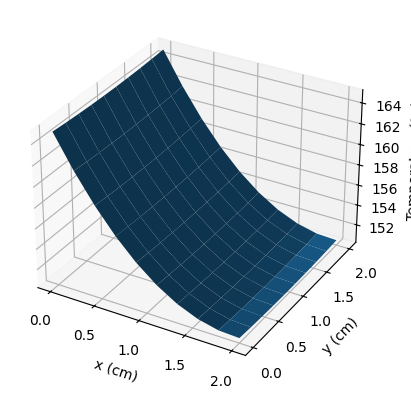

In [32]:

Lx = Ly = 2   
delta = 0.1
P = 5
K = 1.68
H = 0.005
U = 20
n = 10
m = 10
L = 2               
hx = Lx/(m-1)        

breytur = [n, m, H, K, P, delta, Lx, Ly, L]

start = time.perf_counter()

jLoc_use = 0
innriPunktar = set()
for k in range(1, n-1):
    inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
    jLoc_use = jLoc
    for x in inner_row:
        innriPunktar.add(x)

vinstriEfri_A, jLoc0 = makePartOfA(*vinstriEfri(*breytur), jLoc)
vinstriNedri_A, jLoc1 = makePartOfA(*vinstriNedri(*breytur), jLoc0)
nidri_A, jLoc0       = makePartOfA(*nidri(*breytur), jLoc1)
uppi_A, jLoc1        = makePartOfA(*uppi(*breytur), jLoc0)
haegri_A, jLoc0      = makePartOfA(*haegri(*breytur), jLoc1)

megalist = [
    *[x for y in vinstriEfri_A   for x in y],
    *[x for y in vinstriNedri_A  for x in y],
    *[x for y in nidri_A         for x in y],
    *[x for y in uppi_A          for x in y],
    *[x for y in haegri_A       for x in y],
    *[x for y in innriPunktar  for x in y]
]

_, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
length = len(list(set(vinstriNedriRows)))

vinstriNedriRows = np.array(list(set(vinstriNedriRows)))
bValues = np.array([-2*P*hx/(L*delta*K) for _ in range(length)])
columns = np.array([0 for _ in range(length)])

b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)), shape=(n*m, 1)).tocsr()

values, rows, cols = map(np.array, zip(*megalist))
A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

sol = sp.linalg.spsolve(A, b)
end = time.perf_counter()
print(end-start)

u = np.asarray(sol).reshape((n, m))
T = u + U

x = np.linspace(0, Lx, m)
y = np.linspace(0, Ly, n)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, T)  
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_zlabel("Temperature (°C)")
plt.show()

Estimated order: 1.981610768588047


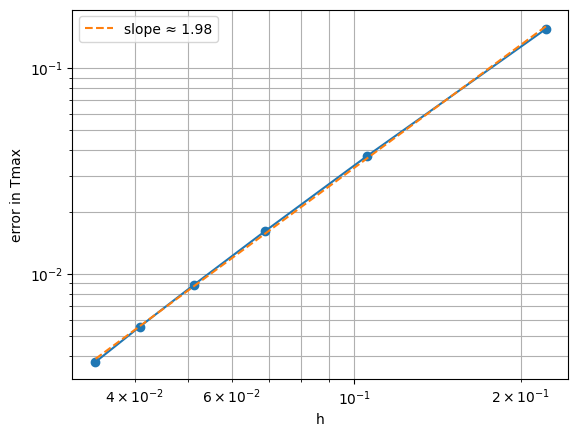

In [33]:


ns = [10, 20, 30, 40, 50, 60]
errors = []
hs = []

Tref, _ = solve_once(200)

for n in ns:
    Tmax, h = solve_once(n)
    errors.append(abs(Tmax - Tref))
    hs.append(h)

hs = np.array(hs)
errors = np.array(errors)

# log-log fit
p, c = np.polyfit(np.log(hs), np.log(errors), 1)

print("Estimated order:", p)

plt.loglog(hs, errors, "o-")
plt.loglog(hs, np.exp(c)*hs**p, "--", label=f"slope ≈ {p:.2f}")
plt.xlabel("h")
plt.ylabel("error in Tmax")
plt.legend()
plt.grid(True, which="both")
plt.show()


0.0028364159998091054


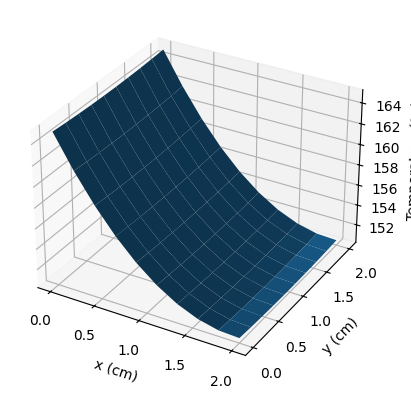

In [34]:
Lx = Ly = 2
delta = 0.1
P = 5
K = 1.68
H = 0.005
U = 20
n = 10
m = 10
L = 2
hx = Lx/(m-1)

breytur = [n, m, H, K, P, delta, Lx, Ly, L]

import time
start = time.perf_counter()

jLoc_use = 0
innriPunktar = set()
for k in range(1, n-1):   
    inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
    jLoc_use = jLoc
    for x in inner_row:
        innriPunktar.add(x)


vinstriEfri_A, jLoc0 = makePartOfA(*vinstriEfri(*breytur), jLoc)
vinstriNedri_A, jLoc1 = makePartOfA(*vinstriNedri(*breytur), jLoc0)
nidri_A, jLoc0 = makePartOfA(*nidri(*breytur), jLoc1)
uppi_A, jLoc1 = makePartOfA(*uppi(*breytur), jLoc0)
haegri_A, jLoc0 = makePartOfA(*haegri(*breytur), jLoc1)

megalist = [
    *[x for y in vinstriEfri_A for x in y],
    *[x for y in vinstriNedri_A for x in y],
    *[x for y in nidri_A for x in y],
    *[x for y in uppi_A for x in y],
    *[x for y in haegri_A for x in y],
    *[x for y in innriPunktar for x in y]
]

_, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
length = len(list(set(vinstriNedriRows)))

vinstriNedriRows = np.array(list(set(vinstriNedriRows)))
bValues = (-2*P*hx/(L*delta*K))*np.ones(length)
columns = np.zeros(length)

b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)), shape=(n*m, 1)).tocsr()

values, rows, cols = map(np.array, zip(*megalist))
A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

sol = sp.linalg.spsolve(A, b)

end = time.perf_counter()

print(end-start)


import numpy as np
import matplotlib.pyplot as plt

u = np.asarray(sol).reshape((n, m))

T = u + 20.0                           

# plt.imshow(T, origin="lower", extent=[0, Lx, 0, Ly], aspect="auto")
# plt.colorbar(label="Temperature (°C)")
# plt.xlabel("x (cm)")
# plt.ylabel("y (cm)")
# plt.show()

x = np.linspace(0, Lx, m)
y = np.linspace(0, Ly, n)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, T)                     
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_zlabel("Temperature (°C)")
plt.show()

0.002340874999845255


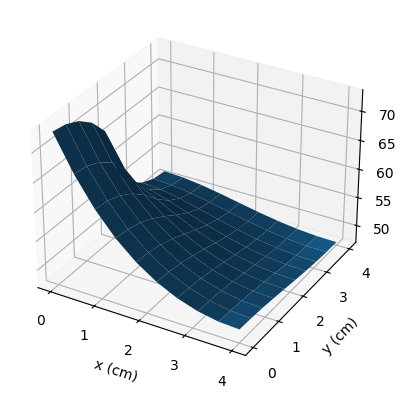

In [35]:
Lx = Ly = 4          # breytt (var 2)
delta = 0.1
P = 5
K = 1.68
H = 0.005
U = 20
n = 10
m = 10
L = 2               
hx = Lx/(m-1)        

breytur = [n, m, H, K, P, delta, Lx, Ly, L]

import time
start = time.perf_counter()

jLoc_use = 0
innriPunktar = set()
for k in range(1, n-1):
    inner_row, jLoc = makePartOfA(*innriRod(*breytur, k), jLoc_use)
    jLoc_use = jLoc
    for x in inner_row:
        innriPunktar.add(x)

vinstriEfri_A, jLoc0 = makePartOfA(*vinstriEfri(*breytur), jLoc)
vinstriNedri_A, jLoc1 = makePartOfA(*vinstriNedri(*breytur), jLoc0)
nidri_A, jLoc0       = makePartOfA(*nidri(*breytur), jLoc1)
uppi_A, jLoc1        = makePartOfA(*uppi(*breytur), jLoc0)
haegri_A, jLoc0      = makePartOfA(*haegri(*breytur), jLoc1)

megalist = [
    *[x for y in vinstriEfri_A   for x in y],
    *[x for y in vinstriNedri_A  for x in y],
    *[x for y in nidri_A         for x in y],
    *[x for y in uppi_A          for x in y],
    *[x for y in haegri_A        for x in y],
    *[x for y in innriPunktar  for x in y]
]

_, vinstriNedriRows, _ = zip(*[x for y in vinstriNedri_A for x in y])
length = len(list(set(vinstriNedriRows)))

vinstriNedriRows = np.array(list(set(vinstriNedriRows)))
bValues = np.array([-2*P*hx/(L*delta*K) for _ in range(length)])
columns = np.array([0 for _ in range(length)])

b = sp.coo_matrix((bValues, (vinstriNedriRows, columns)), shape=(n*m, 1)).tocsr()

values, rows, cols = map(np.array, zip(*megalist))
A = sp.coo_matrix((values, (rows, cols)), shape=(n*m, n*m)).tocsr()

sol = sp.linalg.spsolve(A, b)
end = time.perf_counter()
print(end-start)

u = np.asarray(sol).reshape((n, m))
T = u + U

x = np.linspace(0, Lx, m)
y = np.linspace(0, Ly, n)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, T)  
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_zlabel("Temperature (°C)")
plt.show()






In [36]:
Lx = Ly = 10
delta = 0.1
P = 5
K = 1.68
H = 0.005
U = 20
n = 200
m = 200

results = []

for i in range(Lx-1):
    for j in range(i+1, Lx):
        L = j - i
        run = best_cpu_placement(L=L, POWER_START=i, POWER_END=j)
        results.append((np.mean(run), run, (i, j)))

    
best_result = min(results, key=lambda x: x[0])
plt.imshow(best_result[1], origin="lower", extent=[0, Lx, 0, Ly], aspect="auto")
plt.colorbar(label="Temperature (°C)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.show()
print(f'Best power placement: {best_result[2]} with average temperature {best_result[0]} °C')

x = np.linspace(0, Lx, m)
y = np.linspace(0, Ly, n)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, best_result[1])                     
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_zlabel("Temperature (°C)")
plt.show()

TypeError: 'function' object is not iterable

In [ ]:
target = 100
low, high = 0, 50

for _ in range(40):
    mid = 0.5*(low+high)
    if np.max(best_cpu_placement(P=mid)) > target:
        high = mid
    else:
        low = mid

print("Max allowed power P =", "{:.2f}".format(mid),"[W]")

In [ ]:
target = 100
low, high = 0, 50

K_list = []
P_list = []
for K in range(1,5+1):
    for _ in range(40):
        mid = 0.5*(low+high)
        if np.max(best_cpu_placement(P=mid,K=K)) > target:
            high = mid
        else:
            low = mid

    K_list.append(K)
    P_list.append(mid)

plt.scatter(K_list,P_list,marker='o')
plt.plot(K_list,P_list)
plt.xlabel("K")
plt.ylabel("P")
plt.legend()
plt.grid(True, which="both")
plt.show()